In [1]:
# %pip install tabulate
# %pip install pandas
# %pip install lxml beautifulsoup4
# %pip install openpyxl

# Convenience Store Inventory & Demand Analysis

This notebook analyzes inventory data for a convenience store, calculating sales, profits, and providing recommendations for stock management.

In [2]:
import warnings

warnings.filterwarnings("ignore")

# Data Loading

Load inventory data from markdown file and CSV.

In [3]:
import pandas as pd
import io

with open("data_06_04_2026.md", "r", encoding="utf-8") as f:
    lines = f.readlines()

table = [l for l in lines if "|" in l and "---" not in l]

df = pd.read_table(
    io.StringIO("".join(table)),
    sep="|",
    skipinitialspace=True,
    engine="python",
)

df = df.dropna(axis=1, how="all")

df.columns = df.columns.astype(str).str.strip()
df = df.applymap(lambda x: str(x).strip() if pd.notnull(x) else x)

df.to_csv("mkd_inventory.csv", index=False, encoding="utf-8-sig")

In [4]:
df = pd.read_csv("inventory.csv", encoding="utf-8-sig")

# Rename columns to English
df = df.rename(columns={
    "Producto": "Product",
    "Precio": "Price",
    "Cantidad_miércoles_25_marzo": "Quantity_Wednesday_25_March",
    "Cantidad_jueves_26_marzo": "Quantity_Thursday_26_March",
    "Cantidad_miércoles_1_abril": "Quantity_Wednesday_1_April",
    "Cantidad_lunes_6_abril": "Quantity_Monday_6_April",
    "Viernes_27_marzo_se_compró": "Purchased_Friday_27_March",
    "Martes_31_marzo_se_compró": "Purchased_Tuesday_31_March",
    "Martes_31_marzo_se_sacó": "Removed_Tuesday_31_March",
    "Jueves_2_abril_se_compró": "Purchased_Thursday_2_April",
    "Jueves_2_abril_se_sacó": "Removed_Thursday_2_April",
})

df.head()

,Product,Quantity_Wednesday_25_March,Price,Quantity_Thursday_26_March,Purchased_Friday_27_March,Purchased_Tuesday_31_March,Removed_Tuesday_31_March,Quantity_Wednesday_1_April,Purchased_Thursday_2_April,Removed_Thursday_2_April,Quantity_Monday_6_April
0,Seditas,5,20,5,0,0,0,5,0,0,5
1,Sanitas,42,12,41,0,0,20,29,0,0,27
2,Suavitel morado tapa flor,6,25,6,0,0,0,4,0,0,4
3,Suavitel amarillo tapa flor,3,25,3,0,0,0,1,0,0,1
4,Suavitel amarillo tapa normal,5,25,5,0,0,0,3,6,0,8


# Sales Calculation

In [5]:
print(df.columns.tolist())

['Product', 'Quantity_Wednesday_25_March', 'Price', 'Quantity_Thursday_26_March', 'Purchased_Friday_27_March', 'Purchased_Tuesday_31_March', 'Removed_Tuesday_31_March', 'Quantity_Wednesday_1_April', 'Purchased_Thursday_2_April', 'Removed_Thursday_2_April', 'Quantity_Monday_6_April']


In [6]:
dates = [
    "Quantity_Wednesday_25_March",
    "Quantity_Thursday_26_March",
    "Quantity_Wednesday_1_April",
    "Quantity_Monday_6_April",
]

events_entry = {
    "Quantity_Thursday_26_March": 0,
    "Quantity_Wednesday_1_April": (
        df["Purchased_Friday_27_March"].fillna(0)
        + df["Purchased_Tuesday_31_March"].fillna(0)
        + df["Removed_Tuesday_31_March"].fillna(0)
    ),
    "Quantity_Monday_6_April": (
        df["Purchased_Thursday_2_April"].fillna(0)
        + df["Removed_Thursday_2_April"].fillna(0)
    ),
}

for i in range(len(dates) - 1):
    start = dates[i]
    end = dates[i + 1]

    entries = events_entry.get(end, 0)

    sales_column_name = f"sales_{start}_to_{end}"

    df[sales_column_name] = df[start].fillna(0) + entries - df[end].fillna(0)

df.head()

,Product,Quantity_Wednesday_25_March,Price,Quantity_Thursday_26_March,Purchased_Friday_27_March,Purchased_Tuesday_31_March,Removed_Tuesday_31_March,Quantity_Wednesday_1_April,Purchased_Thursday_2_April,Removed_Thursday_2_April,Quantity_Monday_6_April,sales_Quantity_Wednesday_25_March_to_Quantity_Thursday_26_March,sales_Quantity_Thursday_26_March_to_Quantity_Wednesday_1_April,sales_Quantity_Wednesday_1_April_to_Quantity_Monday_6_April
0,Seditas,5,20,5,0,0,0,5,0,0,5,0,0,0
1,Sanitas,42,12,41,0,0,20,29,0,0,27,1,32,2
2,Suavitel morado tapa flor,6,25,6,0,0,0,4,0,0,4,0,2,0
3,Suavitel amarillo tapa flor,3,25,3,0,0,0,1,0,0,1,0,2,0
4,Suavitel amarillo tapa normal,5,25,5,0,0,0,3,6,0,8,0,2,1


In [7]:
data = []
with open("categories.txt", "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if ":" in line:
            cat, prods = line.split(":", 1)
            data.append({"Category": cat.strip(), "Products": prods.strip()})

df_cat = pd.DataFrame(data)

df_cat["Product"] = df_cat["Products"].str.split(", ")
df_cat = df_cat.explode("Product")

df["Product"] = df["Product"].str.replace("’", "'").str.strip()
df_cat["Product"] = df_cat["Product"].str.replace("’", "'").str.strip()

df["Product"] = df["Product"].str.replace(r"\s+", " ", regex=True).str.strip()
df_cat["Product"] = df_cat["Product"].str.replace(r"\s+", " ", regex=True).str.strip()

df = pd.merge(df, df_cat[["Product", "Category"]], on="Product", how="left")

# df.to_csv("df_with_cat.csv", index=False, encoding="utf-8-sig")

# Category Assignment

Assign categories to products based on categories.txt.

In [8]:
df[df["Category"].isna()]["Product"]

Series([], Name: Product, dtype: object)

# Category Assignment

Assign categories to products based on categories.txt.

In [9]:
df["purchase_price"] = round(df["Price"] / 1.15, 2)
df["price_source"] = "Estimated"


real_prices = {
    "Bubbaloo plátano": 40.20,
    "Bubbaloo mora azul": 40.20,
    "Bubbaloo fresa": 40.20,
    "Bubbaloo tuttifruti": 40.20,
    "Bubbaloo piña chamoy": 40.20,
    "Canels original": 38.25,
    "Mini mamut 28pz": 39.96,
    "Top tops salsa negra": 10.17,
    "Top tops moradas": 10.17,
    "Sol taco extremo": 8.70,
    "Sol taco original": 8.70,
    "Solchesitos queso": 7.10,
    "Solchesitos extremo": 7.00,
    "Sol salsa negra": 12.70,
    "Sol original": 12.60,
    "Sol nachos original": 8.20,
    "Sol jalapeño": 13.10,
    "Sol adobada": 13.10,
    "Sol chipotle": 13.10,
    "Sol extrema": 13.10,
    "Sol habanero": 13.10,
    "Sol limón": 13.10,
    "Sol rifaditas": 13.10,
    "Duvalín fresa vainilla": 28.90,
    "Duvalín avellana vainilla": 29,
    "Duvalín avellana fresa": 29,
    "Pulparindo grande chile": 36.90,
    "Pulparindo original": 36.90,
    "Frutaffy fresa 24pz": 25.20,
    "Winis sirena maxi tubo": 26.90,
    "Winis dragón maxi tubo": 26.90,
    "Winis paleta unicornio": 33.60,
    "Lucas gusano 10pz": 71.30,
    "Suavitel amarillo tapa normal": 20.83,
    "Suavitel azul tapa normal": 20.83,
    "Pétalo jumbo servitoalla": 24.91,
    "Roma 250g": 8.50,
    "Roma 500g": 16.8,
    "Santa Clara entera": 25.83,
    "Santa Clara deslactosada": 25.83,
}


def update_price(row):
    if row["Product"] in real_prices:
        row["purchase_price"] = real_prices[row["Product"]]
        row["price_source"] = "Ticket"
    return row


df = df.apply(update_price, axis=1)

df["unit_profit"] = round(df["Price"] - df["purchase_price"], 2)
df.head()

,Product,Quantity_Wednesday_25_March,Price,Quantity_Thursday_26_March,Purchased_Friday_27_March,Purchased_Tuesday_31_March,Removed_Tuesday_31_March,Quantity_Wednesday_1_April,Purchased_Thursday_2_April,Removed_Thursday_2_April,Quantity_Monday_6_April,sales_Quantity_Wednesday_25_March_to_Quantity_Thursday_26_March,sales_Quantity_Thursday_26_March_to_Quantity_Wednesday_1_April,sales_Quantity_Wednesday_1_April_to_Quantity_Monday_6_April,Category,purchase_price,price_source,unit_profit
0,Seditas,5,20,5,0,0,0,5,0,0,5,0,0,0,Limpieza,17.39,Estimated,2.61
1,Sanitas,42,12,41,0,0,20,29,0,0,27,1,32,2,Limpieza,10.43,Estimated,1.57
2,Suavitel morado tapa flor,6,25,6,0,0,0,4,0,0,4,0,2,0,Limpieza,21.74,Estimated,3.26
3,Suavitel amarillo tapa flor,3,25,3,0,0,0,1,0,0,1,0,2,0,Limpieza,21.74,Estimated,3.26
4,Suavitel amarillo tapa normal,5,25,5,0,0,0,3,6,0,8,0,2,1,Limpieza,20.83,Ticket,4.17


# Price Calculation

Calculate purchase prices and unit profits.

In [10]:
cols = [
    "sales_Quantity_Wednesday_25_March_to_Quantity_Thursday_26_March",
    "sales_Quantity_Thursday_26_March_to_Quantity_Wednesday_1_April",
    "sales_Quantity_Wednesday_1_April_to_Quantity_Monday_6_April",
]

df["total_sold"] = df[cols].sum(axis=1)

product_ranking = df[["Product", "Category", "total_sold"]].sort_values(
    by="total_sold", ascending=False
)

product_ranking

,Product,Category,total_sold
38,Regio verde 600 hojas 4 rollos,Papel,41
1,Sanitas,Limpieza,35
16,Santa Clara entera,Lácteos,24
26,Semanal,Velas,20
42,Quality 600 hojas 6 rollos,Papel,16
...,...,...,...
82,Mazapán original grande,Dulces,0
81,Pica fresa,Dulces,0
79,Pop trueno,Dulces,0
77,Bocadín 50pz,Dulces,0


In [11]:
df[["Product", "purchase_price", "price_source"]]

,Product,purchase_price,price_source
0,Seditas,17.39,Estimated
1,Sanitas,10.43,Estimated
2,Suavitel morado tapa flor,21.74,Estimated
3,Suavitel amarillo tapa flor,21.74,Estimated
4,Suavitel amarillo tapa normal,20.83,Ticket
...,...,...,...
152,Ferrero 24pz 300g,208.70,Estimated
153,Ferrero 4pz 50g,42.61,Estimated
154,Ferrero 10pz 125g,100.00,Estimated
155,Ferrero 8pz 100g,78.26,Estimated


In [12]:
df["total_profit"] = round(df["total_sold"] * df["unit_profit"], 2)
df[["Product", "total_profit"]]

,Product,total_profit
0,Seditas,0.00
1,Sanitas,54.95
2,Suavitel morado tapa flor,6.52
3,Suavitel amarillo tapa flor,6.52
4,Suavitel amarillo tapa normal,12.51
...,...,...
152,Ferrero 24pz 300g,0.00
153,Ferrero 4pz 50g,6.39
154,Ferrero 10pz 125g,30.00
155,Ferrero 8pz 100g,35.22


In [13]:
df["dormant_capital"] = df.apply(
    lambda row: (
        round(row["purchase_price"] * row["Quantity_Monday_6_April"], 2)
        if row["total_sold"] == 0
        else 0
    ),
    axis=1,
)
df[["Product", "purchase_price", "dormant_capital"]]

,Product,purchase_price,dormant_capital
0,Seditas,17.39,86.95
1,Sanitas,10.43,0.00
2,Suavitel morado tapa flor,21.74,0.00
3,Suavitel amarillo tapa flor,21.74,0.00
4,Suavitel amarillo tapa normal,20.83,0.00
...,...,...,...
152,Ferrero 24pz 300g,208.70,417.40
153,Ferrero 4pz 50g,42.61,0.00
154,Ferrero 10pz 125g,100.00,0.00
155,Ferrero 8pz 100g,78.26,0.00


In [14]:
print(f"Total profit generated in 12 days: ${df['total_profit'].sum():.2f}")
print(f"Total dormant capital: ${df['dormant_capital'].sum():.2f}")
print(f"Products with no sales: {(df['total_sold'] == 0).sum()}")

Total profit generated in 12 days: $2107.56
Total dormant capital: $9273.95
Products with no sales: 67


In [15]:
df["no_sales"] = df["total_sold"] == 0
products_no_sales = df[df["no_sales"] == True]["Product"]
products_no_sales.tolist()

df_products_no_sales = pd.DataFrame(products_no_sales)
df_products_no_sales

,Product
0,Seditas
6,Kleenex servitoalla
24,Veladora limonerito
29,Semanal (1/2) grande
34,Blanca Nieves 250g
...,...
149,Picard chocolate tequila
150,Picard chocolate licor de café
151,Gatucos 240g
152,Ferrero 24pz 300g


In [16]:
no_sales_report = (
    df[df["no_sales"] == True]
    .groupby("Category")["Product"]
    .count()
    .sort_values(ascending=False)
)

print("Categories with most stagnant products:")
print(no_sales_report)

Categories with most stagnant products:
Category
Dulces        42
Chocolates    14
Limpieza       4
Botanas        3
Papel          2
Velas          2
Name: Product, dtype: int64


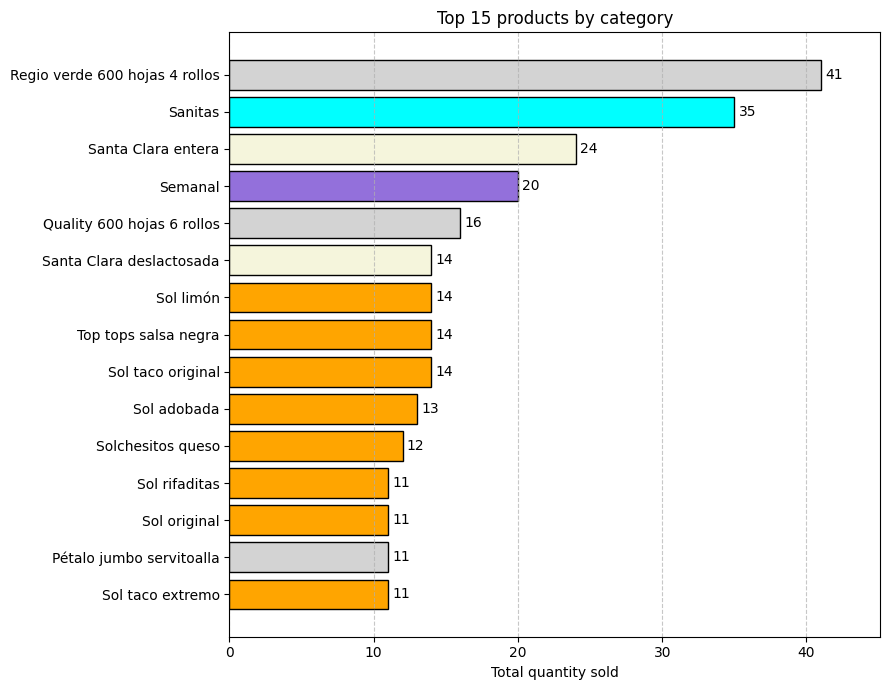

In [17]:
import matplotlib.pyplot as plt

category_translation = {
    "Limpieza": "Cleaning",
    "Papel": "Paper",
    "Lácteos": "Dairy",
    "Velas": "Candles",
    "Dulces": "Sweets",
    "Botanas": "Snacks",
    "Chocolates": "Chocolates",
}

colors_dict = {
    "Cleaning": "cyan",
    "Paper": "lightgray",
    "Dairy": "beige",
    "Candles": "mediumpurple",
    "Sweets": "hotpink",
    "Snacks": "orange",
    "Chocolates": "saddlebrown",
}

top_15 = product_ranking.head(15)
top_15["Category_EN"] = top_15["Category"].map(category_translation)
colors_list = [colors_dict.get(cat, "gray") for cat in top_15["Category_EN"]]

plt.figure(figsize=(9, 7))

bars = plt.barh(
    top_15["Product"], top_15["total_sold"], color=colors_list, edgecolor="black"
)

plt.bar_label(bars, padding=3, fontsize=10)

plt.xlabel("Total quantity sold")
plt.title("Top 15 products by category")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.gca().invert_yaxis()

plt.xlim(0, top_15["total_sold"].max() * 1.1)

plt.tight_layout()
plt.show()

# Visualizations

Plots for top products, profits, and dormant capital.

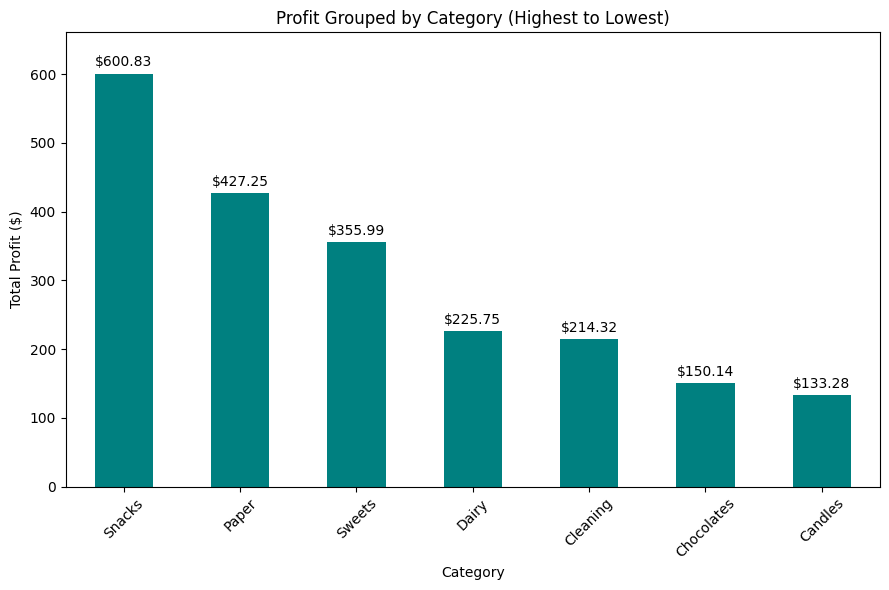

In [18]:
profit_by_category = df.groupby("Category")["total_profit"].sum()
profit_by_category = profit_by_category.sort_values(ascending=False)
profit_by_category.index = profit_by_category.index.map(category_translation)

ax = profit_by_category.plot(kind="bar", color="teal", figsize=(9, 6))

plt.ylabel("Total Profit ($)")
plt.title("Profit Grouped by Category (Highest to Lowest)")

plt.bar_label(ax.containers[0], padding=3, fontsize=10, fmt="$%.2f")
plt.xticks(rotation=45)
plt.ylim(0, profit_by_category.max() * 1.1)

plt.tight_layout()
plt.show()

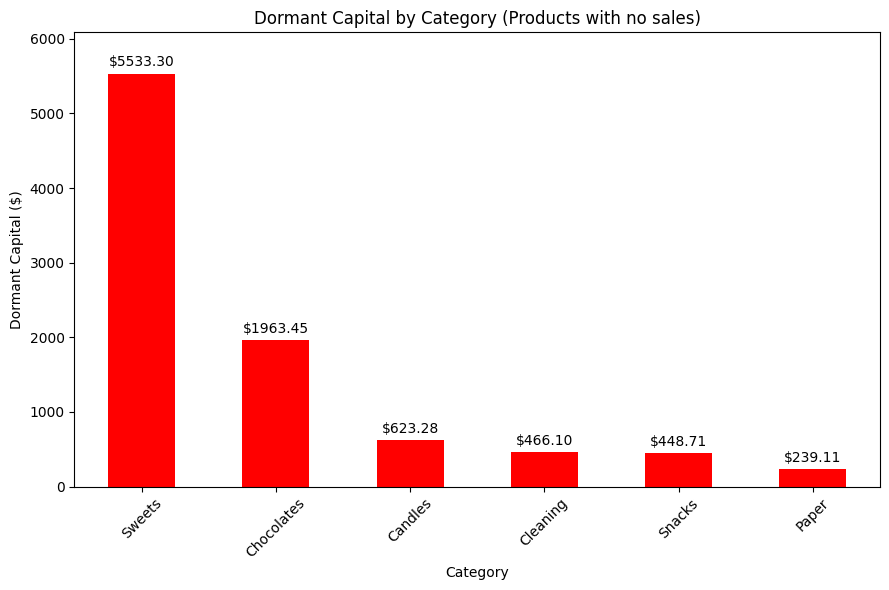

In [19]:
df_dormant = df[df["total_sold"] == 0]

dormant_capital = df_dormant.groupby("Category")["dormant_capital"].sum()
dormant_capital = dormant_capital.sort_values(ascending=False)
dormant_capital.index = dormant_capital.index.map(category_translation)

ax = dormant_capital.plot(kind="bar", color="red", figsize=(9, 6))

plt.ylabel("Dormant Capital ($)")
plt.title("Dormant Capital by Category (Products with no sales)")

plt.bar_label(ax.containers[0], padding=3, fontsize=10, fmt="$%.2f")
plt.xticks(rotation=45)
plt.ylim(0, dormant_capital.max() * 1.1)

plt.tight_layout()
plt.show()

In [20]:
DAYS = 12

df["daily_velocity"] = round(df["total_sold"] / DAYS, 2)
df[["Product", "daily_velocity"]]

,Product,daily_velocity
0,Seditas,0.00
1,Sanitas,2.92
2,Suavitel morado tapa flor,0.17
3,Suavitel amarillo tapa flor,0.17
4,Suavitel amarillo tapa normal,0.25
...,...,...
152,Ferrero 24pz 300g,0.00
153,Ferrero 4pz 50g,0.08
154,Ferrero 10pz 125g,0.17
155,Ferrero 8pz 100g,0.25


In [21]:
DAYS_BETWEEN_PURCHASES = 3

df["recommended_min_stock"] = round(df["daily_velocity"] * DAYS_BETWEEN_PURCHASES, 2)
df["needs_restock"] = df["Quantity_Monday_6_April"] < df["recommended_min_stock"]

restock_filter = df["needs_restock"] == True

result = df[restock_filter][["Product", "recommended_min_stock", "needs_restock"]]

result = result.sort_values(by="recommended_min_stock", ascending=False)

result

,Product,recommended_min_stock,needs_restock
26,Semanal,5.01,True
117,Sol taco original,3.51,True
118,Solchesitos queso,3.00,True
132,Sol original,2.76,True
128,Sol extrema,2.49,True
15,Fabuloso frescura verde,1.26,True
62,Tix tix 30pz,0.75,True
5,Suavitel azul tapa normal,0.51,True
96,Llaves,0.51,True
101,Animalitos,0.24,True


In [22]:
%whos DataFrame

Variable               Type         Data/Info
---------------------------------------------
df                     DataFrame                             <...>\n[157 rows x 25 columns]
df_cat                 DataFrame          Category           <...>n\n[157 rows x 3 columns]
df_dormant             DataFrame                             <...>n\n[67 rows x 22 columns]
df_products_no_sales   DataFrame                             <...>\n\n[67 rows x 1 columns]
product_ranking        DataFrame                             <...>n\n[157 rows x 3 columns]
result                 DataFrame                           Pr<...>      0.24           True
top_15                 DataFrame                             <...>s          11      Snacks


In [23]:
import os

df.to_csv(os.path.join("final_data_frames", "snapshot_2026_04_09.csv"), index=False, encoding="utf-8-sig")
df_cat.to_csv(os.path.join("final_data_frames", "df_cat.csv"), index=False, encoding="utf-8-sig")
df_dormant.to_csv(os.path.join("final_data_frames", "df_dormant.csv"), index=False, encoding="utf-8-sig")
df_products_no_sales.to_csv(os.path.join("final_data_frames", "df_products_no_sales.csv"), index=False, encoding="utf-8-sig")
product_ranking.to_csv(os.path.join("final_data_frames", "product_ranking.csv"), index=False, encoding="utf-8-sig")
top_15.to_csv(os.path.join("final_data_frames", "top_15.csv"), index=False, encoding="utf-8-sig")

# Final Insights and Recommendations

## Key Findings
- Total profit generated over 12 days: Calculated in the notebook (run the cells to see the exact value)
- Total dormant capital (unsold inventory value): Calculated in the notebook
- Number of products with no sales: Calculated in the notebook

## Recommendations
- Focus on restocking high-velocity products like those in the top 15 ranking.
- Consider discontinuing low-turnover categories such as Chocolates and Candles to free up capital.
- Implement the minimum stock recommendations based on 3-day purchase cycles.
- Monitor dormant capital and prioritize faster-moving products for inventory management.

## Validation
- Purchase predictions were validated in the field, with critical items (candles, Sol snacks, fabric softeners) restocked as recommended before the next supply run.